In [12]:
%matplotlib widget

### Imports 😎

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from pbl import PreferenceBasedLearning
from feedback import SimulatedFeedback, SimulatedObjective
from gp import BasicGP
from sampler import RandomSampler

# 1D Objective Function Example

### Set up pyPOLAR Objects

In [16]:
np.random.seed(np.sum([ord(c) for c in 'Dynamic Mobility Lab']))
# construct the PBL class. here, we define our action set.
pbl = PreferenceBasedLearning(low=np.array([0]),
                              high=np.array([6]),
                              action_dims=np.array([50]),
                              preference_noise=0.01,
                              coactive_noise=0.01,
                              ordinal_noise=0.01)

objective = SimulatedObjective(smooth=True,
                               ord_lbls=3,
                               action_space=pbl.action_space,
                               function='1D')
# simulates feedback according to a 1D objective function
fb = SimulatedFeedback(objective=objective, action_space=pbl.action_space) 

# setup the GP model
gp = BasicGP(lengthscale=1, signal_var=1)
gp.setup(pbl.action_space, pbl.overall_likelihood, None) #pbl.preference_jacobian) # assign the action space
                                                   # and likelihood function 
                                                   # from the PBL object

# setup a random sampler to sample actions during data collection
sampler = RandomSampler()

### Train the GP from simulated feedback

In [17]:
epochs = 8 # number of pairwise comparisons to collect
prev = sampler.sample(pbl.action_space)
for idx in range(epochs):
    # this is where you would run the "prev" and "curr" action on your robot and
    # ask a user to compare them...
    
    # collect and add feedback to PBL object
    curr = sampler.sample(pbl.action_space)
    preference, coactive, ordinal = fb.evaluate(curr, prev, get_pairwise=True,
                                                            get_coactive=True,
                                                            get_ordinal=True)
    pbl.add_feedback(preference, coactive, ordinal)

# fit the model
mu = gp.fit(method='BFGS', options={'disp': False})

/Users/neiljanwani/Documents/DynamicMobility/pyPolar/pbl.py:99: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


### Test the accuracy of the fitted model

In [10]:
predictions = 1000
correct = 0
prev = sampler.sample(pbl.action_space)
for i in range(predictions):
    # sample the next action
    curr = sampler.sample(pbl.action_space)
    pred = pbl.predict(gp.mu, curr, prev)
    (_, _, label), _, _ = fb.evaluate(curr, prev, get_pairwise=True)
    correct += int(pred == label[0])
    prev = curr

print(f'Accuracy: {correct / predictions * 100}%')

Accuracy: 89.5%


### Plot the results

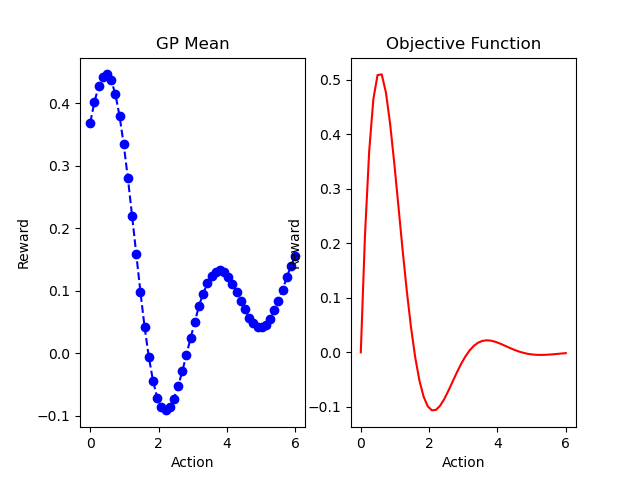

In [11]:
actions = gp.actions.flatten()
fig = plt.figure()
left = fig.add_subplot(121)
right = fig.add_subplot(122)
left.scatter(actions, gp.mu, c='b')
left.plot(actions, gp.mu, c='b', ls='--')
right.plot(actions, objective(actions), c='r')
left.set_title('GP Mean')
right.set_title('Objective Function')
for ax in [left, right]: 
    ax.set_xlabel('Action')
    ax.set_ylabel('Reward')

plt.show()

In [23]:
t = np.arange(0, 6, 0.01)
np.minimum(1, t)

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ,
       1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ,
       1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ,
       1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ,
       1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.